<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 7 - Model Recovery </h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                Notebook author: <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

## Objective
In this TD, you will implement model recovery on several computational models for the bandit task. You will:
- Implement all the steps individually
- Implement the complete model recovery loop
- Produce a confusion matrix
- Produce an inversion matrix

In [1]:
import pandas as pd
from tqdm import trange

from rl_models import RLModel, BiasRLModel, RepeatRLModel
from bandit_task import ReversalBanditTask
from matplotlib import pyplot as plt
import seaborn as sns
import scipy
import numpy as np

## Define the task
For the entire parameter recovery process, we will use the same instance of `ReversalBanditTask`, which is already implemented in the `bandit_task.py` file.

📝Initialize a `ReversalBanditTask` with arm means of 0.4 and 0.6, a reward standard deviation of 0.25, and 100 trials. Plot the task and make sure it is sufficiently difficult.

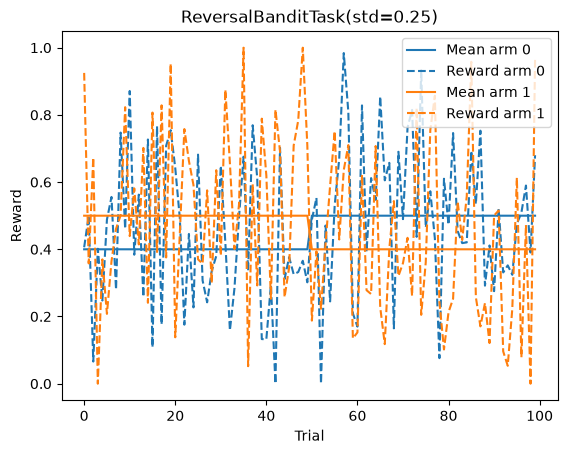

In [2]:
task = ReversalBanditTask(0.4, 0.5, 0.25,n_trials=100)
task.plot()

## Define the models
We will compare three variations of the Reinforcement Learning model. They are already implemented in the `rl_models.py` file and have been imported in this notebook.

The `candidate_models` list below contains the three model classes that you will use for the model recovery. We will reuse it throughout the notebook.

The `model_names` is a list of the model names in string format. It will be used later to display the results of the model recovery in a more readable way.

In [3]:
candidate_models = [RLModel, BiasRLModel, RepeatRLModel]

model_names = [model.__name__ for model in candidate_models]
model_names

['RLModel', 'BiasRLModel', 'RepeatRLModel']

### A) `RLModel`: reinforcement learning model (normal)
The `RLModel` class is a simple Reinforcement Learning model with softmax policy. It has two parameters:
- `learning_rate`: the learning rate used in Q-value updates
- `temperature`: the temperature of the softmax policy

📝 Instantiate an `RLModel` with a learning rate of 0.5 and a temperature of 0.1. Simulate the model on the task and plot its behavior.

_Note_: I have added a `plot` argument to the `simulate()` method of the `RLModel` class. If you set it to True, it will plot the task and the model's behavior during the simulation.

(array([0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0.5       , 0.6154818 , 0.4404634 , 0.84502196, 0.38958121,
        0.58138321, 0.47655412, 0.61716234, 0.77679307, 0.86190631,
        0.97664077, 0.94081177, 0.95222412, 0.90650114, 0.96601684,
        0.82931321, 0.9714712 , 0.9188424 , 0.98301718, 0.93154785,
        0.99160412, 0.85560446, 0.64784663, 0.9013171 , 0.92688932,
        0.91247042, 0.75784932, 0.61630976, 0.75860748, 0.62807669,
        0.86902671, 0.78694985, 0.97014688, 0.96995829, 0.89975184,
        0.90193569, 0.98967786, 0.73016509, 0.87207581, 0.70585742,
        0.94454951, 0.9511399 , 0.7687268 , 0.95822646, 0.97014465,
        0.81489076, 0.75860366, 0.9169556 , 0.

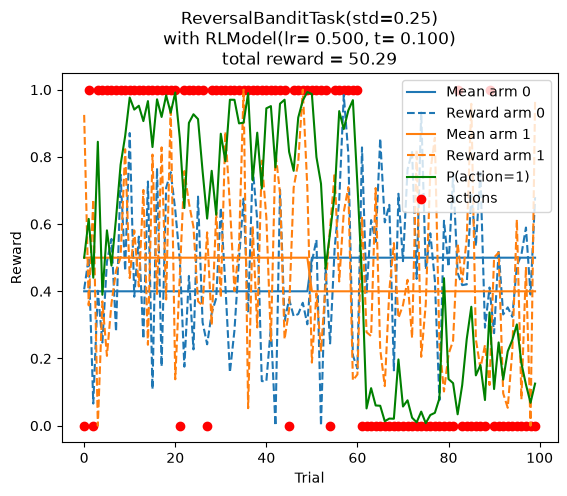

In [4]:
rl_model = RLModel(0.5,0.1)
rl_model.simulate(task, plot=True)

### B) `BiasRLModel`: Reinforcement learning model with action bias
The `BiasRLModel` class implements a reinforcement learning model with a bias towards action 1. It has three parameters:
- `learning_rate` : the learning rate of the model
- `temperature` ($\tau$): the temperature of the softmax policy
- `bias` ($b$): the bias towards action 1 (between -0.2 and 0.2)

The softmax policy of this model gives the probability of choosing action 1 at a trial $t$ according to the following equation:
$$
p_t = \frac{1}{ 1 + \exp(-\frac{Q^1_t - Q^0_t + b}{\tau})}
$$


📝Instantiate a `BiasRLModel` with a learning rate of 0.5, a temperature of 0.1, and a bias of 0.1. Simulate the model on the task and plot its behavior.

(array([1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1]),
 array([0.73105858, 0.95790426, 0.79457148, 0.88497422, 0.2729317 ,
        0.3452926 , 0.35859539, 0.29117742, 0.43429526, 0.56160476,
        0.89221156, 0.75554308, 0.79341634, 0.76084722, 0.86624729,
        0.72176809, 0.86231971, 0.55000044, 0.92385101, 0.83167944,
        0.98259026, 0.76462189, 0.67707822, 0.91769352, 0.94123615,
        0.93054918, 0.80226107, 0.67650772, 0.81731325, 0.62224068,
        0.84269632, 0.73069692, 0.95792923, 0.95669837, 0.85854854,
        0.86078537, 0.66630123, 0.86104855, 0.89409986, 0.68608715,
        0.9141047 , 0.96526189, 0.87762505, 0.96849017, 0.99293917,
        0.97162161, 0.96319563, 0.99295758, 0.

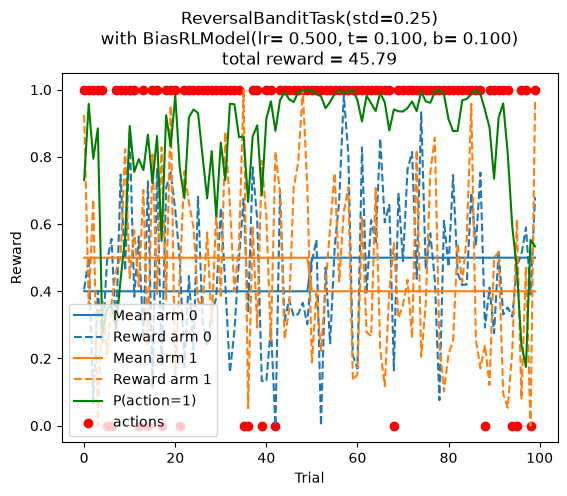

In [5]:
bias_model = BiasRLModel(0.5,0.1,0.1)
bias_model.simulate(task, plot=True)

### C) `RepeatRLModel`: Reinforcement learning model with repeat bias
The `RepeatRLModel` class implements a reinforcement learning model with a bias towards repeating the previous action. It has three parameters:
- `learning_rate` : the learning rate of the model
- `temperature` ($\tau$): the temperature of the softmax policy
- `repeat` ($\gamma$): the bias towards repeating the previous action (between -0.2 and 0.2)

The softmax policy of this model gives the probability of choosing action 1 at a trial $t$ according to the following equation:
$$
p_t = \frac{1}{ 1 + \exp(-\frac{Q^1_t - Q^0_t + \gamma \cdot 2(a_{t-1} - 0.5)}{\tau})}
$$
Where $a_{t-1}$ is the action (0 or 1) taken at trial $t-1$.

In more simple terms, this softmax policy computes the difference between the Q-values of action 1 and 0 and gives a bonus of $\gamma$ to the action that was taken at the previous trial, so it has more chances of being selected again.

📝Instantiate a `RepeatRLModel` with a learning rate of 0.5, a temperature of 0.1, and a reapeat bias of 0.1. Simulate the model on the task and plot its behavior.

(array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0]),
 array([0.5       , 0.37061351, 0.68150969, 0.87864024, 0.55879745,
        0.79113577, 0.51710986, 0.55461457, 0.26040784, 0.04686594,
        0.07141081, 0.01222174, 0.05369034, 0.04734494, 0.17549203,
        0.04064077, 0.29383308, 0.79198289, 0.97407018, 0.92463887,
        0.9920952 , 0.87238371, 0.88170559, 0.97363224, 0.98084276,
        0.97678604, 0.92662669, 0.66426415, 0.74704619, 0.89361354,
        0.96543647, 0.37715902, 0.43295289, 0.75911843, 0.9292608 ,
        0.40080873, 0.98672047, 0.71577118, 0.05060151, 0.04431523,
        0.71509023, 0.74449273, 0.33397853, 0.77649793, 0.83140255,
        0.40073831, 0.27613829, 0.16744017, 0.

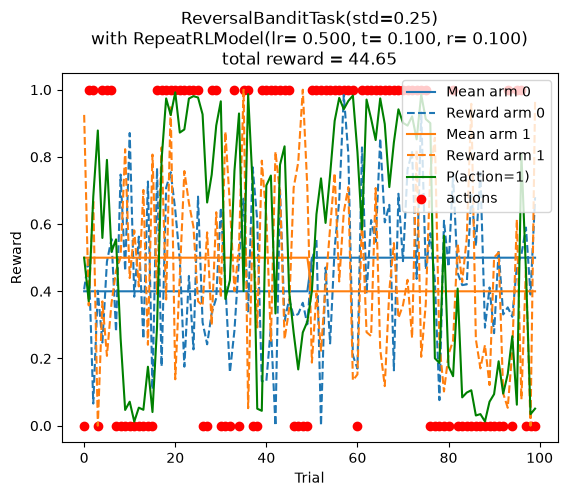

In [6]:
repeat_model = RepeatRLModel(0.5,0.1,0.1)
repeat_model.simulate(task, plot=True)

## Parameter distributions
Like we did during parameter recovery, we will sample the parameters of the models from a distribution. This is done to make sure that the model recovery is not biased by the parameter values we choose. For this exercise, we will define all distributions in a dictionary called `param_distributions`.

>_Implementation note_: If you perform cognitive modeling on very different models in a future project, you should to consider each set of distributions to its model class to make your code more manageable. But to keep it simple, today we will define all distributions in the same dictionary.

📝 Define a distribution for each parameter of the models. Re-use the settings you used in the last TD for the parameters you already know. For the two bias terms (action bias and repeat bias), you can use a uniform distribution between -0.2 and 0.2

>⚠️ Remember that the `scipy.stats.uniform` constructor is a bit peculiar. It does not take the bounds of the distribution directly. The first argument (`loc`) is the lower bound of the distribution, and the second argument (`scale`) is the range of the distribution.

In [7]:
param_distributions = {
    'learning_rate': scipy.stats.uniform(0.01, 0.1),
    'temperature': scipy.stats.expon(scale=0.1),
    'bias': scipy.stats.uniform(-0.2, 1),
    'repeat': scipy.stats.uniform(-0.2, 1)
}

Use the `distplay_distributions` function below to visualize the distributions of the parameters. For each parameter, check that the following elements are correct:
- The bounds of the distribution
- The shape of the distribution (uniform, exponential, normal, etc.)

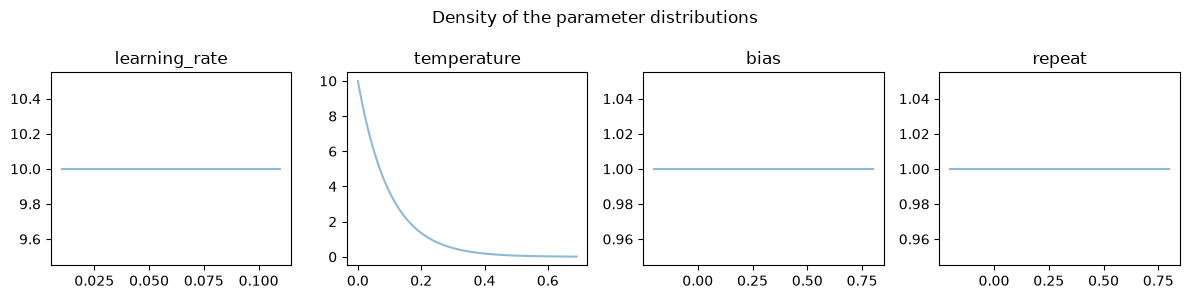

In [8]:
def display_distributions(distributions):
    fig, axs = plt.subplots(1, len(distributions), figsize=(len(distributions) * 3, 3))
    for i, (param, dist) in enumerate(distributions.items()):
        ax = axs[i]
        x = np.linspace(dist.ppf(0.001), dist.ppf(0.999), 100)
        y = dist.pdf(x)
        ax.plot(x, y, alpha=0.5)
        ax.set_title(param)
    fig.suptitle('Density of the parameter distributions')
    plt.tight_layout()

display_distributions(param_distributions)

## Model Recovery, Step by Step
Before jumping into the full model recovery loop, let's start simple.
We will start by simulating a behavior with the RLModel only. Then we will fit the three candidate models to its behavior and we will pick the best candidate model using the Bayesian Information Criterion (BIC).

We will proceed in 4 steps:
1. Instantiate the 'simulating' model
2. Simulate behavior
3. Fit all candidate models to the behavior
4. Select the winning model among the candidates

### 1) Instantiate the 'simulating' model
📝Instantiate an `RLModel` with parameters whose values are samples from their distributions and assign it to the `simulating_model` variable.

In [9]:
sampled_lr = param_distributions['learning_rate'].rvs() # Sample a learning rate from the appropriate distribution
sampled_temp = param_distributions['temperature'].rvs() # Sample a temperature from the appropriate distribution

simulating_model = RLModel(sampled_lr, sampled_temp) # Create an instance of the RLModel with the sampled parameters

### 2) Simulate a behavior with the 'simulating' model
📝 Simulate a behavior with the `simulating_model` on the `task` and collect its `actions` and associated `rewards`

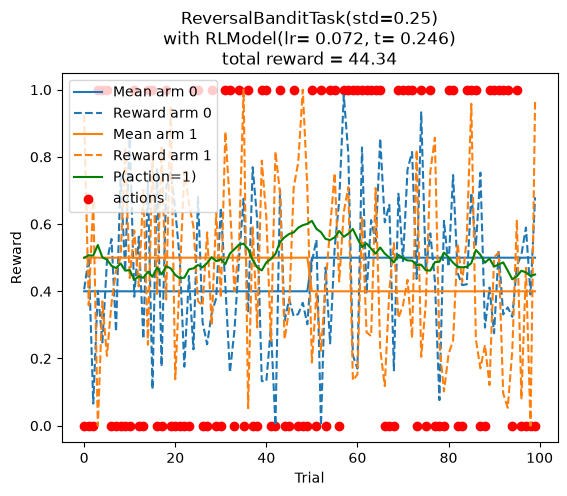

In [10]:
actions, _, rewards = simulating_model.simulate(task, plot=True) # Simulate the model on the task and plot the results

### 3) Fit candidate models
⚙️ Fit all candidate models to the simulated behavior. Use the `fit()` method of each model. Store the fitted models in a list called `fitted_models`.

>_Implementation note:_
> The syntax you see below is called a *list comprehension*. It is a way to create a list in one line of code. It is the equivalent of a _for loop_, but it is more compact and often more readable. The syntax is as follows:
>```python
>result = [item.do_something() for item in list]   
>```
> - - - - - - - - - -
>Which is the equivalent of this for loop:
>```python
>result = []
>for item in list:
>    result.append(item.do_something())
>```

In [11]:
fitted_models = [model.fit(actions, rewards) for model in candidate_models]
fitted_models

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         100.231               1                                 Uncertainty test


     0           6         74.3215               1         Initial mesh            Initial points
     0           7         69.6752               1       Successful poll           Train
     1           8         69.3143               1     Incremental search (ES-wcm)        
     1          13         69.3119             0.5         Refine grid             
     2          15         68.8799             0.5     Successful search (ES-wcm)        
     2          16          68.651             0.5     Incremental search (ES-ell)        
     2          24          68.651            0.25         Refine grid             
     3          26         68.5263            0.25     Incremental search (ES-ell)        
     3          32         68.5014           0.125         Refine grid             Train
     4          33         68.1869           0.125     Successful search (ES-ell)        
     4          34         67.8861           0.125     Successful search (ES-ell)        
     4       

[RLModel(lr= 0.004, t= 0.006),
 BiasRLModel(lr= 0.003, t= 0.004, b=-0.001),
 RepeatRLModel(lr= 0.003, t= 0.004, r= 0.000)]

### 4) Select the best among the fitted candidate models
#### a) Compute the log likelihoods
We have learned that log likelihood is a way to measure how a model is likely to have produced a behavior. Let's first compute it for all candidate models.

📝 Compute the log likelihood of the simulated behavior for each fitted candidate model. Use the `log_likelihood` method of each model. Store the log likelihoods in a list called `ll`.

⚠️ Make sure you keep the same model order in all your lists throughout this section!

In [12]:
ll = [model.log_likelihood(actions, rewards) for model in fitted_models]

📝 Display the log-likelihoods in a Pandas Series where the model names are used as the index.

In [13]:
pd.Series(
    data=ll,
    index=model_names,
    name='log likelihood'
)

RLModel         -66.594562
BiasRLModel     -66.328043
RepeatRLModel   -66.485139
Name: log likelihood, dtype: float64

💭 What model seems to fit the data best? Do you remember how to interpret log likelihoods?


BiasModel seems to fit the data best because it has the highest loglikelihood


💭What model seems to be the worst fit? How can you explain that?

Le pire est RLModel car il a le plus petit log likelihood, ce qui signifie qu'il est le moins probable d'avoir généré les données observées. Cela s'explique par le fait que RLModel n'a pas de biais ni de répétition, ce qui le rend moins flexible pour s'adapter aux données. BiasRLModel et RepeatRLModel ont des paramètres supplémentaires qui leur permettent de mieux capturer les tendances dans les données, ce qui se traduit par un log likelihood plus élevé.

#### b) Bayesian Information Criterion (BIC)
The Bayesian Information Criterion (BIC) is a model selection criterion that is designed to allow the comparison of models with different numbers of parameters. It gives a penalty to models with more parameters, which helps  avoid overfitting. The BIC is defined as:
$$
\text{BIC} = -2 \cdot \log L + k \cdot \log n
$$
Where:
- $L$ is the likelihood of the behavior given the fitted model
- $k$ is the number of parameters in the model
- $n$ is the number of data points

📝Complete the `bayesian_information_criterion` function to compute the BIC of a model given the actions and rewards.

In [14]:
def bayesian_information_criterion(model, actions, rewards) -> float:
    k = model.n_params # (This class attribute is part of the implementation of the model classes)
    n = actions.shape[0]
    ll = model.log_likelihood(actions, rewards)
    bic = k * np.log(n) - 2 * ll
    return bic

📝 Compute the BIC for each fitted candidate model and store the results in a list called `bics`.

In [15]:
bics = [bayesian_information_criterion(model, actions, rewards) for model in fitted_models]

📝 Display the BICs in a Pandas Series with the model names as index.

In [16]:
pd.Series(
    data=bics,
    index=model_names,
    name='BIC'
)

RLModel          142.399464
BiasRLModel      146.471597
RepeatRLModel    146.707374
Name: BIC, dtype: float64

💭 What model seems to fit the data best now? From the mathematical definition of BIC, can you figure out if a higher or a lower BIC is better?

A lower BIC value indicates a better model fit, taking into account the number of parameters in the model.

💭 Is the `RLModel` still the worst model according to the Bayesian Information Criterion? Does this criterion seem to take account the number of parameters correctly?

The RLModel is the best now, the BIC is the lowest for this model. This means that the RLModel is the best model to explain the data generated by the simulating_model, which is also an RLModel. The BIC takes account of the number of parameters in the model, so it penalizes models with more parameters. The RLModel has fewer parameters than the other two models, which is why it has a lower BIC.

#### c) Model selection
Now that we have a criterion to select the best model, we can use it to select the best model among the fitted models. We will need to write a function to do this for us.

📝Complete the `select_model` function to compute the BIC of all models and selecting the one with the best BIC. It should return the index of the selected model ('index' being an integer, here: 0, 1 or 2).

>_Notes_:
>- You can (and should!) reuse the `bayesian_information_criterion()` function that you defined previously
>- To return the index of the maximum or the minimum of a list, you can use the functions `np.argmax()` or `np.argmin()`.

In [17]:
def select_model(fitted_models, actions, rewards) -> int:
    bics = [bayesian_information_criterion(model, actions, rewards) for model in fitted_models]
    return np.argmin(bics)  # Return the index of the model with the best BIC

select_model(fitted_models, actions, rewards) # Call the function with the appropriate arguments

np.int64(0)

## Model Recovery Loop
### Initializing a matrix to collect the outcomes
Before we start the model recovery procedure, we need a matrix that keeps the counts of which candidate model wins on each simulation. So for each simulation, we have a **simulating model** and a **recovered model**, both of which are one of the **candidate models**.

📝Initialize your `results` DataFrame as a 3 x 3 matrix filled with 0s. The `index` (row names) and `columns` (column names) should both be the candidate model names. Verify that the DataFrame you create is well formatted before you move on.

In [20]:
results = pd.DataFrame(
    data=0,
    index=model_names,
    columns=model_names
)
results

,RLModel,BiasRLModel,RepeatRLModel
RLModel,0,0,0
BiasRLModel,0,0,0
RepeatRLModel,0,0,0


### The loop
Now we will write a loop where we specify a number of iterations in which we will simulate behaviors with all three models, and try to fit each of them with all three models as well.

📝 Fill the missing code in the loop below. The previous section of the TD was meant to help you understand what code needs to be written in each part. We did the simulation with the `RLModel` only, but now you will need to perform simulations with all models.

>Notes:
>- The `results.iloc[i, j]` syntax allows you to set a value on a DataFrame in the cell corresponding to the row of index i and column of index j.
>- You might want to set `verbose=False` in the `fit()` method to avoid printing the optimization process.
>- When you test and debug your code, set `n_rounds=1` to avoid long computation times. Then set it back to 10 (or even 100 if you have a powerful computer) to run the full simulation.
>- In your future projects, you will want to use parallel computing to speed up this loop

In [21]:
n_rounds = 10

for i in trange(n_rounds):

    ### Simulate with RLModel ###
    # 1) Instantiate the model with parameters sampled from their distributions
    rl_model = RLModel(
        learning_rate=param_distributions['learning_rate'].rvs(),
        temperature=param_distributions['temperature'].rvs()
    )
    # 2) Simulate a behavior with the model
    actions, _, rewards = rl_model.simulate(task, plot=False)
    # 3) Fit all candidate models to the behavior
    fitted_models = [model.fit(actions, rewards) for model in candidate_models]
    # 4) Select the model with the best BIC
    selected_model = select_model(fitted_models, actions, rewards)
    # 5) Save the outome in `results`
    # Increment the corresponding cell in the results DataFrame
    # Here the first row corresponds to a simulated RLModel, and the column corresponds to the winning model
    results.iloc[0, selected_model] += 1


    ### Simulate with BiasRLModel ###
    # Now you do the same, but the behavior is simulated with the BiasRLModel
    bias_model = BiasRLModel(
        learning_rate=param_distributions['learning_rate'].rvs(),
        temperature=param_distributions['temperature'].rvs(),
        bias=param_distributions['bias'].rvs()
    )
    actions, _, rewards = bias_model.simulate(task, plot=False)
    fitted_models = [model.fit(actions, rewards) for model in candidate_models]
    selected_model = select_model(fitted_models, actions, rewards)
    results.iloc[1, selected_model] += 1


    ### Simulate with RepeatRLModel ###
    # Again, you do the same, but the behavior is simulated with the RepeatRLModel
    repeat_model = RepeatRLModel(
        learning_rate=param_distributions['learning_rate'].rvs(),
        temperature=param_distributions['temperature'].rvs(),
        repeat=param_distributions['repeat'].rvs()
    )
    actions, _, rewards = repeat_model.simulate(task, plot=False)
    fitted_models = [model.fit(actions, rewards) for model in candidate_models]
    selected_model = select_model(fitted_models, actions, rewards)
    results.iloc[2, selected_model] += 1

  0%|          | 0/10 [00:00<?, ?it/s]

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         64.6886               1                                 Uncertainty test
     0           6         58.8563               1         Initial mesh            Initial points
     0           9         58.2519             0.5         Refine grid             Train
     1          13         55.1106             0.5     Successful search (ES-wcm)        
     1          15         54.0808             0.5     Successful search (ES-wcm)        
     1          17          50.056             0.5     Successful search (ES-wcm)        
     1          21         49.6899             0.5     Successful search (ES-ell)        
     1          23         49.4043             0.5     Incremental search (ES-ell)        
     1          24         49.3679      

 10%|█         | 1/10 [00:23<03:29, 23.30s/it]

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         80.0109               1                                 Uncertainty test
     0           6         65.1309               1         Initial mesh            Initial points
     0           7         61.4939               1       Successful poll           Train
     1          13         61.4939             0.5         Refine grid             Train
     2          15         58.9405             0.5     Successful search (ES-wcm)        
     2          19         58.4004             0.5     Successful search (ES-wcm)        
     2          20         58.2758             0.5     Incremental search (ES-wcm)        
     2          23         58.2214             0.5     Incremental search (ES-wcm)        
     2          25         58.1992      

 20%|██        | 2/10 [00:37<02:21, 17.73s/it]

...

 80%|████████  | 8/10 [03:00<00:47, 23.97s/it]

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         95.4534               1                                 Uncertainty test
     0           6         71.7011               1         Initial mesh            Initial points
     0           7         68.4289               1       Successful poll           Train
     1          13         68.4289             0.5         Refine grid             Train
     2          17         68.1565             0.5     Incremental search (ES-ell)        
     2          19         68.1565            0.25         Refine grid             Train
     3          21         68.1491            0.25     Incremental search (ES-wcm)        
     3          27         68.1491           0.125         Refine grid             
     4          28         68.0682           0.

 90%|█████████ | 9/10 [03:22<00:23, 23.35s/it]

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         69.4908               1                                 Uncertainty test
     0           6          61.673               1         Initial mesh            Initial points
     0           7         57.9906               1       Successful poll           Train
     1          13         57.9906             0.5         Refine grid             Train
     2          15         49.8351             0.5     Successful search (ES-wcm)        
     2          24         49.8351            0.25         Refine grid             
     3          25         49.2603            0.25     Successful search (ES-ell)        
     3          28         49.0073            0.25     Successful search (ES-ell)        
     3          29         48.9633            0.

100%|██████████| 10/10 [03:43<00:00, 22.37s/it]


Visualize your results

In [22]:
results

,RLModel,BiasRLModel,RepeatRLModel
RLModel,10,0,0
BiasRLModel,1,9,0
RepeatRLModel,1,3,6


## Confusion Matrix
The confusion matrix is a table that reports the results of your model recovery as the proportion of times each candidate model was selected among all simulations made with a given a simulating model.

It is meant to answer questions such as: "If I simulate a behavior with the RLModel, what is the probability that RLModel, or BiasRLModel, or RepeatRLModel will win as best model?"

In other words, this matrix should be read **row by row** (for each simulated model), and each cell contains the probability
$P(\text{winning} | \text{simulated})$.

📝Compute the confusion matrix by dividing all the values in the `results` DataFrame by the number of rounds.

In [35]:
confusion_matrix = results/n_rounds
confusion_matrix

,RLModel,BiasRLModel,RepeatRLModel
RLModel,1.0,0.0,0.0
BiasRLModel,0.1,0.9,0.0
RepeatRLModel,0.1,0.3,0.6


📝Plot the confusion matrix with a heatmap:
- Add annotations to show the values with 2 decimal places
- Add a title
- Add x and y labels
- Make sure the x axis is the winning model and the y axis is the simulated model

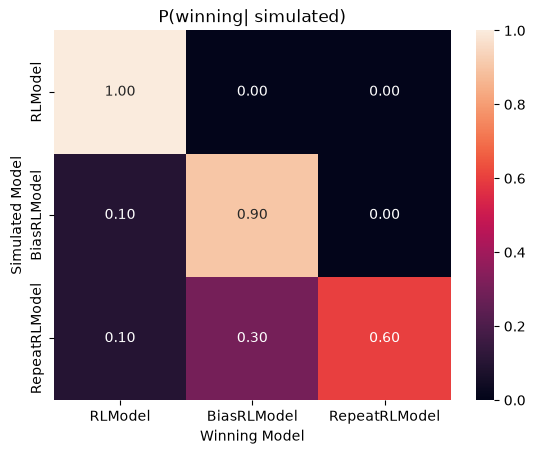

In [29]:
# Your code here
sns.heatmap(confusion_matrix, annot=True, fmt='.2f')
plt.title(f"P(winning| simulated)")
plt.xlabel('Winning Model')
plt.ylabel('Simulated Model')
plt.show()

💭In a confusion matrix, if you remember, is it the rows or the columns that should sum to 1? Is it the case in your graph?

## Inversion Matrix
The inversion matrix is very similar to the confusion matrix, but the condition is inverted.

This allows us to ask questions such as: "If the BiasRLModel is the winner in my analysis, what is the probability the behavior was simulated with the RLModel, or BiasRLModel, or RepeatRLModel?"

This type of question is the one we ask ourselves when we do computational modelling. In other words, the inversion matrix can be read **column by column**, for every winning model, and each cell contains the probability $P(\text{simulated} | \text{winning})$.

📝 Compute the `inversion_matrix` by normalizing the `confusion_matrix` column-wise (i.e., each column should sum to 1).

In [36]:
inversion_matrix = confusion_matrix.div(confusion_matrix.sum(axis=0), axis=1)  # Normalize each row to sum to 1
inversion_matrix

,RLModel,BiasRLModel,RepeatRLModel
RLModel,0.833333,0.00,0.0
BiasRLModel,0.083333,0.75,0.0
RepeatRLModel,0.083333,0.25,1.0


📝 Plot the inversion matrix in a heatmap

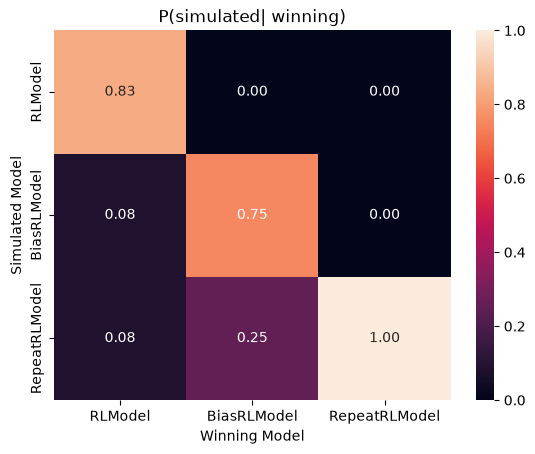

In [37]:
# Your code here
sns.heatmap(inversion_matrix, annot=True, fmt='.2f')
plt.title(f"P(simulated| winning)")
plt.xlabel('Winning Model')
plt.ylabel('Simulated Model')
plt.show()

💭How do you interpret the inversion matrix? What cells do you need to pay attention to? What does it tell your ability to use those models in your analysis?

In [40]:
The inversion matrix is read **column by column**: each cell estimates \(P(\text{simulated model} \mid \text{winning model})\).

The diagonal cells indicate how reliably a winning model identifies the true generating model. Here, the results suggest that:

- A winning `RLModel` corresponds to the true model in about 83% of cases.
- A winning `BiasRLModel` corresponds to the true model in 75% of cases.
- A winning `RepeatRLModel` corresponds to the true model in 100% of cases.

The off-diagonal cells show possible misidentifications. These are especially important when interpreting a winning `BiasRLModel`, since 25% of those cases were actually generated by `RepeatRLModel`.

Thus, the `RepeatRLModel` appears easiest to identify, while the other models can occasionally be confused. The inversion matrix suggests that model-selection results should be interpreted cautiously, rather than assuming that the winning model is always the true model.

SyntaxError: invalid syntax (2972830306.py, line 1)

💭The diagonal line of your confusion and inversion matrices are probably a bit different from each other. How do you interpret this difference? Would you have told the same story if you had only looked at the confusion matrix to decide if your modelling procedure is reliable?

## 💪💪Optional exercise: Win-Stay-Lose-Switch
Implement the Win-stay lose-switch model (you decide the implementation, but it should have at least one free parameter). Then, modify your model selection code to take it into account. See how it compares to the other three models.

In [ ]:
class WinStayLoseSwitch:
    ...

In [ ]:
...